# Updating Survival Analysis (Era 1 vs Era 2)
This notebook analyzes the Out-of-Hospital Cardiac Arrest (OHCA) clinical dataset to determine if patient survival outcomes have significantly changed between two distinct operational eras: 
* **Era 1:** 2010–2017 
* **Era 2:** 2018–2021

I will be using the  Kaplan-Meier estimator to visualize the probability of survival relative to EMS response times (`TimeCallScene`), and the Log-Rank test to determine statistical significance.

# Need to install decruption Libraries

In [64]:
%pip install msoffcrypto-tool openpyxl

Note: you may need to restart the kernel to use updated packages.


# Install libraries

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import msoffcrypto
import io
import openpyxl

from pathlib import Path
from datetime import datetime
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Get the password from env

In [66]:
password = os.getenv("PAROS_PASSWORD")

if not password:
    print("ERROR: Password not found in the env")
else:
    print("SUCCESS: Password found in the env")

SUCCESS: Password found in the env


# Setting up file paths

In [67]:
CURRENT_DIRECTORY = Path(os.getcwd())
BASE_DATASET_PATH = CURRENT_DIRECTORY.parents[0] / "datasets"
ENCRYPTED_FILE_PATH = BASE_DATASET_PATH / "DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx"

display(ENCRYPTED_FILE_PATH)


PosixPath('/Users/axlee/Desktop/Singhealth/AED-OHCA/datasets/DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx')

# Decrypting the file

In [68]:
decrypted_workbook = io.BytesIO()
print(f"Attempting to decrypt: {ENCRYPTED_FILE_PATH.name}...")

try:
    with open(ENCRYPTED_FILE_PATH, 'rb') as file:
        office_file = msoffcrypto.OfficeFile(file)
        office_file.load_key(password=password)
        office_file.decrypt(decrypted_workbook)

    # Load the decrypted memory object directly into a Pandas DataFrame
    df = pd.read_excel(decrypted_workbook)
    print("✅ RAW PAROS dataset successfully decrypted and loaded!")
    
    # Show the first 3 rows to confirm
    display(df.head(3))

except FileNotFoundError:
    print(f"❌ Error: Could not find the file at {ENCRYPTED_FILE_PATH}. Please check the path and filename.")
except openpyxl.utils.exceptions.InvalidFileException:
    print("❌ Error: Invalid password or unsupported Excel format.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

Attempting to decrypt: DataExportParos_SG_Apr10-Dec21_with postal codes_27Mar25_encryptedv1.xlsx...


/opt/miniconda3/envs/geospatial_env/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


✅ RAW PAROS dataset successfully decrypted and loaded!


,Case #,Country,City,Site #,Patient brought in by,Date of Incident,Location of incident,Location Unknown,Location Type,Location Type Other,...,EQ-5D Unknown,EQ-5D Mobility,EQ-5D Self-care,EQ-5D Usual activities,EQ-5D Pain/Discomfort,EQ-5D Anxiety/Depression,EQ-5D VAS,General Comments,Date Created,Date Last Saved
0,SGSIN0213,SG,SIN,2,EMS,2010-04-01,470146.0,NaN,Home Residence,HDB Level 7,...,NaN,,,,,,NaN,,,2011-02-22
1,SGSIN0218,SG,SIN,2,EMS,2010-04-01,520926.0,NaN,Home Residence,HDB Level 2,...,NaN,,,,,,NaN,,,2011-02-22
2,SGSIN6480,SG,SIN,6,EMS,2010-04-01,560565.0,NaN,Healthcare Facility,NKF Dialysis Centre,...,NaN,,,,,,NaN,,,2012-04-18


# Creating the Eras

In [69]:
df['Date of Incident'].dtype

dtype('<M8[ns]')

In [70]:
df['Date of Incident'] = pd.to_datetime(df['Date of Incident'],
                                        format='mixed',
                                        errors='coerce')
df['Year'] = df['Date of Incident'].dt.year

era1 = df[(df['Year'] >= 2010) & (df['Year'] <= 2017)].copy()
era2 = df[(df['Year'] >= 2018) & (df['Year'] <= 2021)].copy()

print(f"Era 1 (2010-2017) patient count: {len(era1)}")
print(f"Era 2 (2018-2021) patient count: {len(era2)}")

Era 1 (2010-2017) patient count: 15390
Era 2 (2018-2021) patient count: 13275


# Kaplan-Meier Survival Curves

I will plot the survival probability against the EMS response time (Time from Call to Scene Arrival). 
* **Duration (`T`):** `TimeCallScene` (Minutes)
* **Event (`E`):** `Survival` (1 = Survived, 0 = Died)

# Define variables based on PAROS data dictionary

In [71]:
event_col = 'Outcome of patient'
start_col = 'Time call received at dispatch center'
end_col = 'Time Ambulance arrived at scene'

# Clean missing values and outliers

In [72]:
#  Drop rows with missing values in our target columns
era1_clean = era1.dropna(subset=[start_col, end_col, event_col]).copy()
era2_clean = era2.dropna(subset=[start_col, end_col, event_col]).copy()

print(f"Era 1 records after dropping completely blank rows: {len(era1_clean)}")
print(f"Era 2 records after dropping completely blank rows: {len(era2_clean)}")

Era 1 records after dropping completely blank rows: 15132
Era 2 records after dropping completely blank rows: 12052


In [83]:
# Convert time columns to datetime
era1_clean['Start'] = pd.to_datetime(era1_clean[start_col].astype(str), errors='coerce')
era1_clean['End'] = pd.to_datetime(era1_clean[end_col].astype(str), errors='coerce')

era2_clean['Start'] = pd.to_datetime(era2_clean[start_col].astype(str), errors='coerce')
era2_clean['End'] = pd.to_datetime(era2_clean[end_col].astype(str), errors='coerce')

/var/folders/y3/l8mcqj111md_2kpwgj8zhk0w0000gn/T/ipykernel_6780/3035661728.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  era1_clean['Start'] = pd.to_datetime(era1_clean[start_col].astype(str), errors='coerce')
/var/folders/y3/l8mcqj111md_2kpwgj8zhk0w0000gn/T/ipykernel_6780/3035661728.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  era1_clean['End'] = pd.to_datetime(era1_clean[end_col].astype(str), errors='coerce')
/var/folders/y3/l8mcqj111md_2kpwgj8zhk0w0000gn/T/ipykernel_6780/3035661728.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  era2_clean['Start'] = pd.

In [84]:
# Calculate duration strictly in minutes (End minus Start)
era1_clean['Time'] = (era1_clean['End'] - era1_clean['Start']).dt.total_seconds() / 60.0
era2_clean['Time'] = (era2_clean['End'] - era2_clean['Start']).dt.total_seconds() / 60.0

# If a call crossed midnight (e.g., 23:55 to 00:05), it creates a negative number. Add 24 hrs back)
era1_clean.loc[era1_clean['Time'] < 0, 'Time'] += 1440
era2_clean.loc[era2_clean['Time'] < 0, 'Time'] += 1440

In [85]:
# Find 'Admitted' for both Eras. 1 = Admitted (Lived), 0 = Died in ED
era1_clean['Event'] = era1_clean[event_col].astype(str).str.contains('Admitted', case=False, na=False).astype(int)
era2_clean['Event'] = era2_clean[event_col].astype(str).str.contains('Admitted', case=False, na=False).astype(int)

In [87]:
# Final drop of any NaNs that occurred during datetime conversion
era1_final = era1_clean.dropna(subset=['Time', 'Event']).copy()
era2_final = era2_clean.dropna(subset=['Time', 'Event']).copy()

print(f"Valid Era 1 records with calculated minutes: {len(era1_final)}")
print(f"Valid Era 2 records with calculated minutes: {len(era2_final)}")

Valid Era 1 records with calculated minutes: 15132
Valid Era 2 records with calculated minutes: 12052


# Initialize the Kaplan-Meier Fitters and fitting the plot

In [88]:
kmf_era1 = KaplanMeierFitter()
kmf_era2 = KaplanMeierFitter()

# Plotting the graph

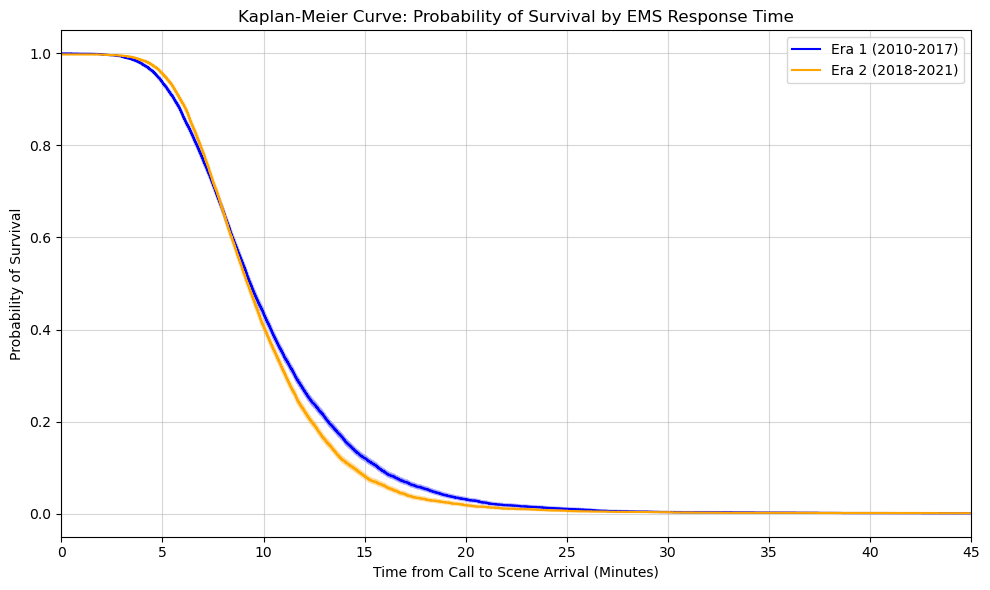

In [92]:
plt.figure(figsize=(10, 6))
ax = plt.subplot(111)

# Fit Era 1 and invert it so curve correctly drops as mortality occurs over time
kmf_era1.fit(durations=era1_final['Time'],
             event_observed=(1 - era1_final['Event']),
             label='Era 1 (2010-2017)')
kmf_era1.plot_survival_function(ax=ax, ci_show=True, color='blue')

# Fit Era 2
kmf_era2.fit(durations=era2_final['Time'],
             event_observed=(1 - era2_final['Event']),
             label='Era 2 (2018-2021)')
kmf_era2.plot_survival_function(ax=ax, ci_show=True, color='orange')

# Limit X-axis to 45 minutes
plt.xlim(0, 45)

plt.title('Kaplan-Meier Curve: Probability of Survival by EMS Response Time')
plt.xlabel('Time from Call to Scene Arrival (Minutes)')
plt.ylabel('Probability of Survival')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()